##### -Usar o data set carros_usados.csv e criar modelos de regressão para prever o preço de carros usados
##### -Começar por usar regressão linear e depois random forest e xgboost
##### -Apresentar tabela compartiva das metricas desses modelos

In [1]:
## Import libraries

import pandas as pd
import numpy as np
import seaborn as sns


In [2]:
df = pd.read_csv('../dataset/carros_usados.csv')
df.sample(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
51902,Up,2019,9998,Manual,20,Petrol,145.0,54.3,1.0,vw
68049,Ioniq,2018,16998,Automatic,11776,Hybrid,135.0,78.5,1.6,Hyundai
13643,1 Series,2019,19998,Semi-Auto,7222,Petrol,150.0,47.9,2.0,BMW
42101,Golf,2016,14291,Semi-Auto,57600,Diesel,30.0,62.8,2.0,vw
20256,1 Series,2016,9995,Manual,30000,Diesel,0.0,83.1,1.5,BMW
60966,Avensis,2013,5995,Manual,101300,Diesel,30.0,61.4,2.0,toyota
1869,R8,2013,47995,Manual,19834,Petrol,570.0,19.6,4.2,audi
50779,Tiguan,2017,20981,Semi-Auto,52286,Diesel,145.0,49.6,2.0,vw
21324,1 Series,2017,9600,Manual,58023,Diesel,20.0,68.9,2.0,BMW
8454,A1,2019,20930,Automatic,5756,Petrol,150.0,47.1,1.0,audi


EDA

In [3]:
df.shape

(72435, 10)

In [4]:
# mostra dados muito diferentes portanto
# grande dispersao de valores

df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16580.158708,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.028754,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


In [5]:
# dtype - float - int - object(number,number,texto)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  object 
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  object 
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  object 
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [6]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

In [7]:
# modelos unicos

unique_models = df['model'].unique()
print(f"Unique models count: {len(unique_models)}")
print(unique_models)

Unique models count: 146
[' A1' ' A6' ' A4' ' A3' ' Q3' ' Q5' ' A5' ' S4' ' Q2' ' A7' ' TT' ' Q7'
 ' RS6' ' RS3' ' A8' ' Q8' ' RS4' ' RS5' ' R8' ' SQ5' ' S8' ' SQ7' ' S3'
 ' S5' ' A2' ' RS7' ' 5 Series' ' 6 Series' ' 1 Series' ' 7 Series'
 ' 2 Series' ' 4 Series' ' X3' ' 3 Series' ' X5' ' X4' ' i3' ' X1' ' M4'
 ' X2' ' X6' ' 8 Series' ' Z4' ' X7' ' M5' ' i8' ' M2' ' M3' ' M6' ' Z3'
 ' Fiesta' ' Focus' ' Puma' ' Kuga' ' EcoSport' ' C-MAX' ' Mondeo' ' Ka+'
 ' Tourneo Custom' ' S-MAX' ' B-MAX' ' Edge' ' Tourneo Connect'
 ' Grand C-MAX' ' KA' ' Galaxy' ' Mustang' ' Grand Tourneo Connect'
 ' Fusion' ' Ranger' ' Streetka' ' Escort' ' Transit Tourneo' ' T-Roc'
 ' Golf' ' Passat' ' T-Cross' ' Polo' ' Tiguan' ' Sharan' ' Up'
 ' Scirocco' ' Beetle' ' Caddy Maxi Life' ' Caravelle' ' Touareg'
 ' Arteon' ' Touran' ' Golf SV' ' Amarok' ' Tiguan Allspace' ' Shuttle'
 ' Jetta' ' CC' ' California' ' Caddy Life' ' Caddy' ' Caddy Maxi' ' Eos'
 ' Fox' ' GT86' ' Corolla' ' RAV4' ' Yaris' ' Auris' ' Aygo' '

In [8]:
# marcas unicas
unique_models = df['Make'].unique()
print(f"Unique models count: {len(unique_models)}")
print(unique_models)

Unique models count: 7
['audi' 'BMW' 'Ford' 'vw' 'toyota' 'skoda' 'Hyundai']


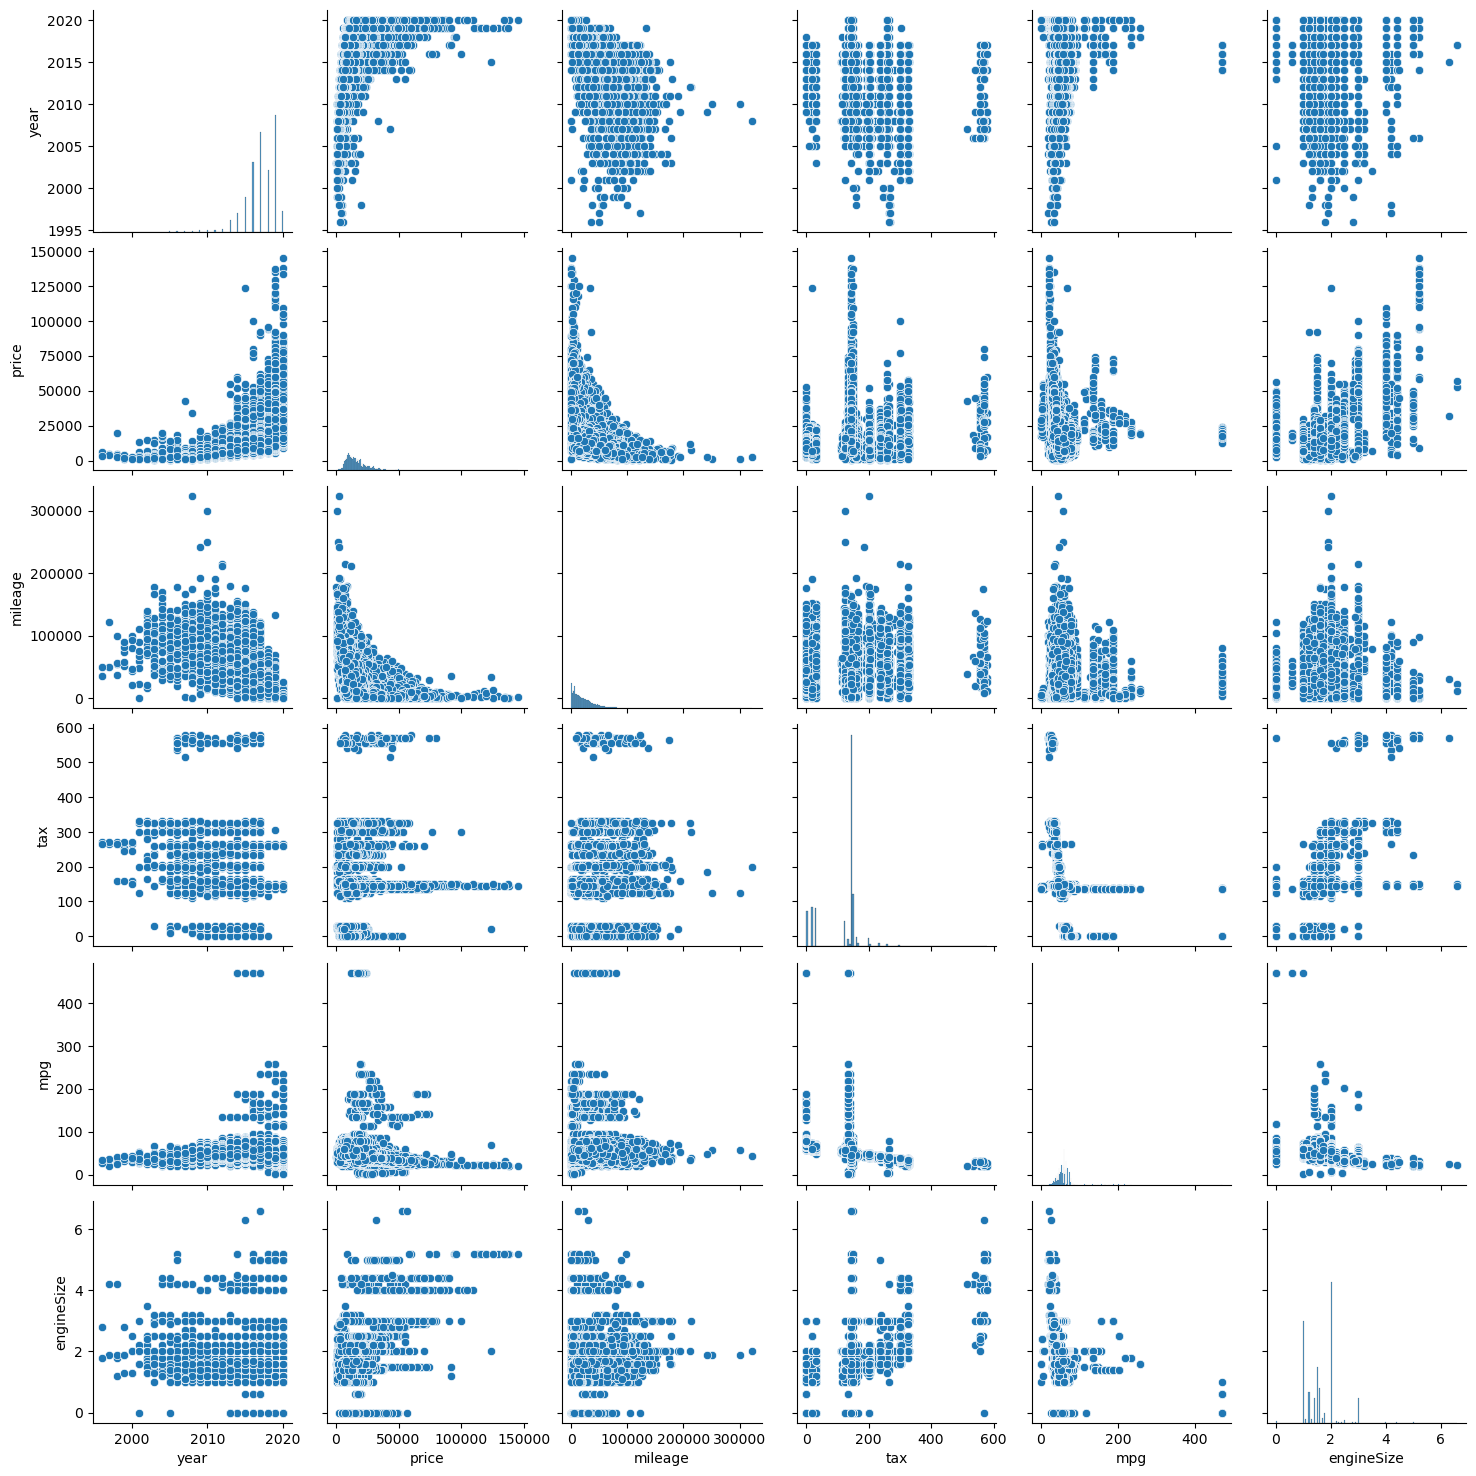

In [9]:
sns.pairplot(df)
#grafico serve para ver outliers e relacoes entre as variaveis
# ajudar as decicoes para o pre processamento dos dados(tratar de outliers fazer scaling, etc)
#price vs milage que e uma relacao negativa nao linear que o preço tende a cair quando a kilometragem aumenta
#relaçao positiva - price vs year carros mais novos tendem a ser mais caros

<Axes: >

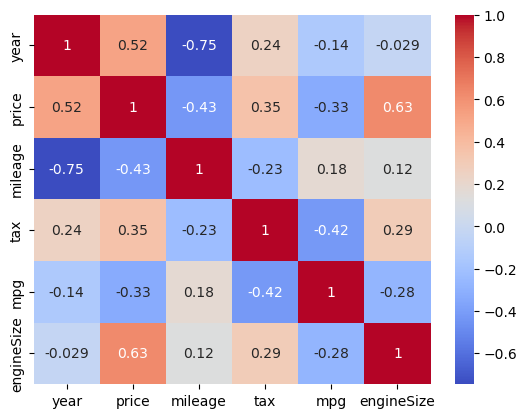

In [10]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
# celulas com correlação maior que 0.5 - forte
# celulas com correlação entre 0.3 e 0.5 - moderada
# celulas com correlação entre 0.1 e 0.3 - fraca
# celulas com correlação menor que 0.1 - muito fraca ou inexistente

## Pre processamento


In [11]:
cols_to_check = ['mpg','engineSize','tax']  # variaveis que nao podem ter zeros para diesol ou petrol
for c in cols_to_check:
    print(c, ((df['fuelType'].isin(['Petrol','Diesel'])) & (df[c]==0)).sum())

mpg 0
engineSize 190
tax 4514


In [12]:
import numpy as np
cols_to_fix = ['mpg','engineSize','tax']

# vai buscar aos carros que estiverem em petrol ou diesel e vai substiruir os zeros por NaN
# nao faz nada nos carros eletricos ou hibridos porque eles podem ter zeros nessas variaveis
mask = df['fuelType'].isin(['Petrol','Diesel'])
for c in cols_to_fix:
    df.loc[mask & (df[c] == 0), c] = np.nan

In [13]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

cols_to_encode = ['model','transmission','fuelType','Make']

encoded_data = encoder.fit_transform(df[cols_to_encode])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cols_to_encode), index=df.index)

df = pd.concat([df, encoded_df], axis=1) # adiciona as colunas codificadas
df = df.drop(columns=cols_to_encode) # remove as colunas originais

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Columns: 168 entries, year to Make_vw
dtypes: float64(165), int64(3)
memory usage: 92.8 MB


## Treino com Regressão linear

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Y = df['price']
X = df.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

print("Train R2:", reg.score(X_train_scaled, y_train))
print("Test R2:", reg.score(X_test_scaled, y_test))

NameError: name 'df' is not defined

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results_df = pd.DataFrame(columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2'])

def evaluate(reais, previstos):
    mse = mean_squared_error(reais, previstos)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(reais, previstos)
    r2 = r2_score(reais, previstos)
    return round(mse, 2), round(rmse, 2), round(mae, 2), round(r2, 4)

def print_evaluate(model, reais, previstos):
    mse, rmse, mae, r2 = evaluate(reais, previstos)
    print('__________________________________')
    print('Model:', model)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('MAE:', mae)
    print('R2:', r2)
    print('__________________________________')
    results = np.array([model, mse, rmse, mae, r2], dtype=object)
    results_df.loc[len(results_df)] = results